In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Step 2: Load Dataset
data = pd.read_csv("titanic.csv")


print("First 5 rows of the dataset:")
display(data.head())

print("\nDataset Info:")
data.info()


First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB



 Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 Survival Rate:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6316\1271018413.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=data, palette='pastel')


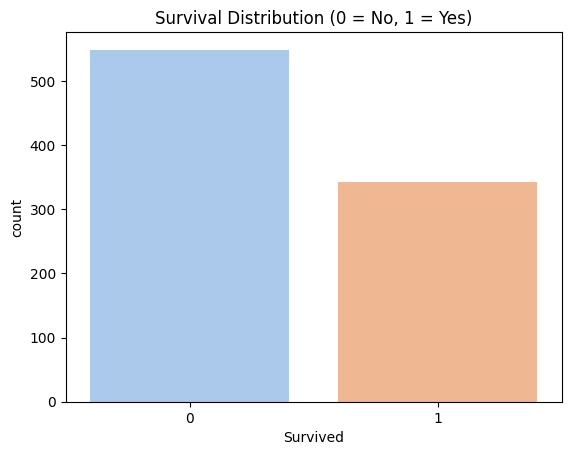

In [3]:
# Step 3: Explore the Dataset
print("\n Missing Values per Column:")
print(data.isnull().sum())

print("\n Survival Rate:")
print(data['Survived'].value_counts(normalize=True) * 100)

# Visualize survival count
sns.countplot(x='Survived', data=data, palette='pastel')
plt.title('Survival Distribution (0 = No, 1 = Yes)')
plt.show()


In [4]:
# Step 4: Data Cleaning

data['Age'].fillna(data['Age'].median(), inplace=True)

data.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)

data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

print("Missing Values After Imputation:")

print(data.isnull().sum())

Missing Values After Imputation:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6316\3327466943.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6316\3327466943.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [5]:
 # Encode categorical variables
label = LabelEncoder()
data['Sex'] = label.fit_transform(data['Sex'])

In [6]:

data = pd.get_dummies(data, columns=['Embarked', 'Pclass'], drop_first=True)

# Check cleaned data
print("Cleaned Dataset Preview:")
display(data.head())

Cleaned Dataset Preview:


,PassengerId,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,1,0,1,22.0,1,0,7.2500,False,True,False,True
1,2,1,0,38.0,1,0,71.2833,False,False,False,False
2,3,1,0,26.0,0,0,7.9250,False,True,False,True
3,4,1,0,35.0,1,0,53.1000,False,True,False,False
4,5,0,1,35.0,0,0,8.0500,False,True,False,True


In [7]:
# Step 5: Train-Test Split

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")


Training Samples: 712
Testing Samples: 179


In [9]:
# Step 6: Model Building (Training the Model)

# Import the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Create the model
model = RandomForestClassifier(
    n_estimators=100,       # Number of trees in the forest
    random_state=42,        # For reproducibility
    max_depth=None,         # Expand trees fully unless limited
    min_samples_split=2,    # Minimum samples to split a node
    min_samples_leaf=1,     # Minimum samples at leaf node
)

# Train the model on training data
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

print("Model training complete and predictions generated.")


Model training complete and predictions generated.


In [10]:
# Step 7: Make Predictions
y_pred = model.predict(X_test)

In [11]:
# Step 8: Evaluate Model
print("Model Evaluation Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation Results:
Accuracy: 82.68%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



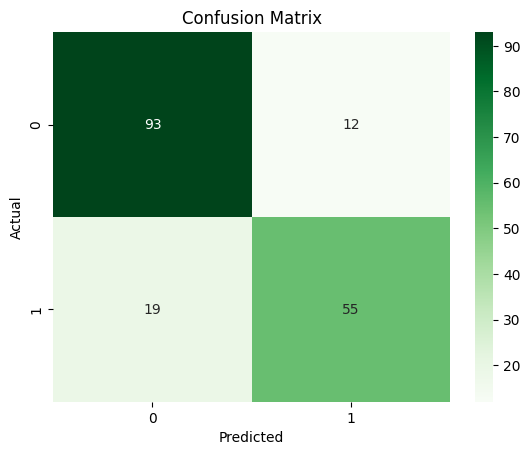

In [12]:
# Step 9: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()